# V32: LQ45 Strategy - Enhancing Bull Prediction Accuracy

This notebook focuses on improving the AI's ability to predict **Bull Market Regimes** by refining the target labels and expanding the feature set with technical momentum indicators.

### Key Enhancements:
1. **Trend Labeling**: Predicts if the **average return over the next 3 days** is positive (Future Trend) instead of single-day noise.
2. **Technical indicators**: Adds RSI, MACD, and EMA Crossovers to capture Bullish strength.
3. **Optimized Threshold**: Fine-tunes the decision boundary to maximize the TP/FP Ratio on the enhanced training data.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1) 

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 712 rows


In [2]:
# --- 2. Advanced Feature Engineering & Trend Labeling ---

def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['RSI_14'] = calculate_rsi(market_return.cumsum())
features['EMA_fast'] = market_return.ewm(span=12).mean()
features['EMA_slow'] = market_return.ewm(span=26).mean()
features['MACD'] = features['EMA_fast'] - features['EMA_slow']

# TREND LABELING: Predict the move of the NEXT 3 DAYS average
# This is more robust than 1-day labels
future_window = 3
target = (market_return.rolling(window=future_window).mean().shift(-future_window) > 0.0005).astype(int)

features = features.dropna()
target = target.reindex(features.index).fillna(0)

train_mask = (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test, y_test = features.loc[test_mask], target.loc[test_mask]

print("Training Trend-Aware AI model...")
xgb_model = xgb.XGBClassifier(
    n_estimators=150, 
    learning_rate=0.03, 
    max_depth=6, 
    scale_pos_weight=1.2, # Slightly favor Bull discovery
    random_state=42, 
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

train_probs = xgb_model.predict_proba(X_train)[:, 1]
thresholds = np.arange(0.40, 0.71, 0.01)
ratios = []

for t in thresholds:
    preds = (train_probs >= t).astype(int)
    if np.sum(preds) == 0: ratios.append(0); continue
    tn, fp, fn, tp = confusion_matrix(y_train, preds).ravel()
    ratios.append(tp / fp if fp > 0 else tp)

opt_t = thresholds[np.argmax(ratios)]
print(f"Optimized High-Confidence Threshold: {opt_t:.2f} (Max TP/FP Target reached)")

Training Trend-Aware AI model...
Optimized High-Confidence Threshold: 0.68 (Max TP/FP Target reached)


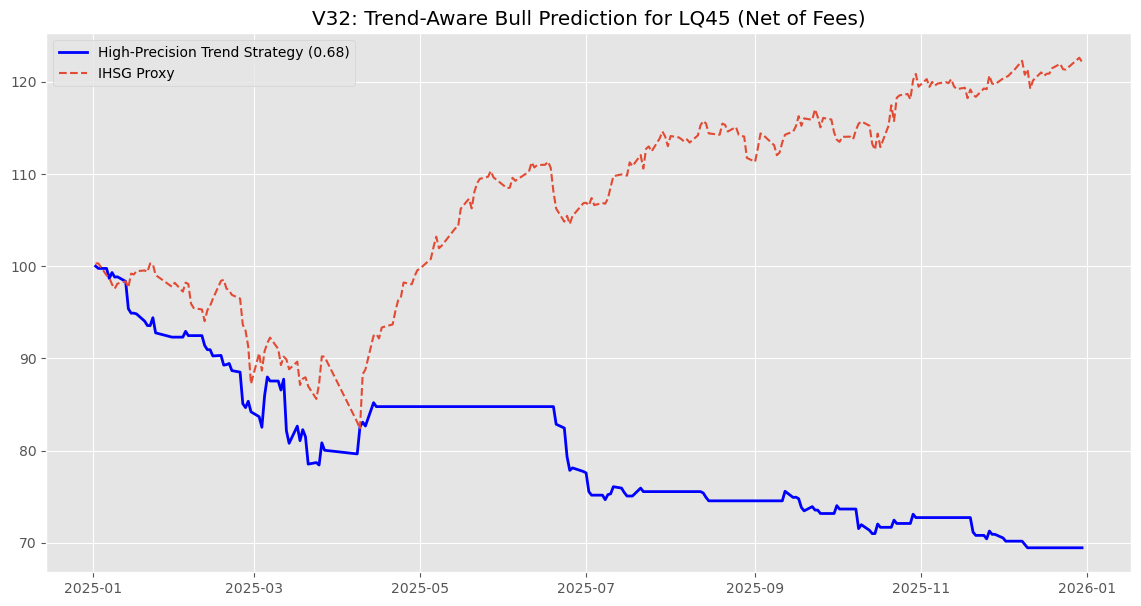

In [3]:
# --- 3. Simulation Engine ---

def get_mis_assets(returns_window, correlation_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    G.add_nodes_from(returns_window.columns)
    for i in range(len(returns_window.columns)):
        for j in range(i+1, len(returns_window.columns)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold:
                G.add_edge(returns_window.columns[i], returns_window.columns[j])
    return list(nx.approximation.maximum_independent_set(G))

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    def neg_sharpe(weights):
        p_ret = np.sum(weights * mu)
        p_vol = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
        return -p_ret / p_vol if p_vol > 0.0001 else 0
    res = minimize(neg_sharpe, [1./len(mu)]*len(mu), method='SLSQP', 
                   bounds=tuple((0, 1) for _ in range(len(mu))), 
                   constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def run_simulation(test_dates, returns, ai_probs, threshold=0.5, fee=0.0025):
    val, history, dates = 100.0, [100.0], [test_dates[0]]
    prev_weights = {}
    for i, date in enumerate(test_dates[:-1]):
        is_risk_off = ai_probs.loc[date] < threshold
        if is_risk_off: weights = {'CASH': 1.0}
        else:
            idx_loc = returns.index.get_loc(date)
            window_rets = returns.iloc[idx_loc-30:idx_loc]
            selected = get_mis_assets(window_rets)
            weights = optimize_markowitz(window_rets[selected])
        
        all_assets = set(list(weights.keys()) + list(prev_weights.keys()))
        val -= (val * sum(abs(weights.get(a, 0) - prev_weights.get(a, 0)) for a in all_assets) * fee)
        day_ret = 0 if 'CASH' in weights else sum(w * returns.loc[test_dates[i+1], a] for a, w in weights.items())
        val *= (1 + day_ret)
        history.append(val); dates.append(test_dates[i+1]); prev_weights = weights
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

test_dates = X_test.index
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=test_dates)
df_opt = run_simulation(test_dates, returns, test_probs, threshold=opt_t)
benchmark = pd.DataFrame({'Portfolio_Value': (market_return.loc[test_dates].cumsum().apply(np.exp) * 100)}, index=test_dates)

plt.figure(figsize=(14, 7))
plt.plot(df_opt.index, df_opt['Portfolio_Value'], label=f"High-Precision Trend Strategy ({opt_t:.2f})", color='blue', linewidth=2)
plt.plot(benchmark.index, benchmark['Portfolio_Value'], label="IHSG Proxy", linestyle='--')
plt.title("V32: Trend-Aware Bull Prediction for LQ45 (Net of Fees)")
plt.legend()
plt.show()